<a href="https://colab.research.google.com/github/kazi-amir/ml-learning/blob/main/pytorch-5-projects/1-rice-type-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download Dataset

In [1]:
import re

# Paste your Kaggle dataset URL here
dataset_url = "https://www.kaggle.com/datasets/mssmartypants/rice-type-classification"

# Extract the owner/name from the URL
match = re.search(r'datasets/([^/]+/[^/?#]+)', dataset_url)
if match:
    dataset_slug = match.group(1)
    print(f"Downloading dataset: {dataset_slug}")
    !kaggle datasets download -d {dataset_slug}
    !unzip -o *.zip
else:
    print("Could not parse Kaggle URL. Please check the format.")

Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification
License(s): copyright-authors
100% 888k/888k [00:00<00:00, 100MB/s]

Archive:  rice-type-classification.zip
  inflating: riceClassification.csv  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
data_df = pd.read_csv("/content/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
data_df.shape

(18185, 12)

In [7]:
data_df.drop(["id"], axis=1, inplace=True)
data_df.shape

(18185, 11)

In [8]:
data_df.isna().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0
AspectRation,0


In [9]:
print(data_df["Class"].nunique())
print(data_df["Class"].unique())

2
[1 0]


In [10]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [11]:
list(data_df.columns)

['Area',
 'MajorAxisLength',
 'MinorAxisLength',
 'Eccentricity',
 'ConvexArea',
 'EquivDiameter',
 'Extent',
 'Perimeter',
 'Roundness',
 'AspectRation',
 'Class']

In [12]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             18185 non-null  int64  
 1   MajorAxisLength  18185 non-null  float64
 2   MinorAxisLength  18185 non-null  float64
 3   Eccentricity     18185 non-null  float64
 4   ConvexArea       18185 non-null  int64  
 5   EquivDiameter    18185 non-null  float64
 6   Extent           18185 non-null  float64
 7   Perimeter        18185 non-null  float64
 8   Roundness        18185 non-null  float64
 9   AspectRation     18185 non-null  float64
 10  Class            18185 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 1.5 MB


In [13]:
X = np.array(data_df.iloc[:,:-1])
y = np.array(data_df.iloc[:, -1])

In [14]:
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
  )
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test,
    y_val_test,
    test_size=0.5,
    random_state=42
  )

In [15]:
X_train.shape, X_val.shape, X_test.shape

((12729, 10), (2728, 10), (2728, 10))

In [16]:
y_train.shape, y_val.shape, y_test.shape

((12729,), (2728,), (2728,))

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [19]:
class dataset(Dataset):
  def __init__(self, X, Y):
    self.X = torch.tensor(X, dtype=torch.float32).to(device)
    self.Y = torch.tensor(Y, dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]

In [20]:
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
test_data = dataset(X_test, y_test)

In [21]:
training_dataloader = DataLoader(training_data, batch_size=16, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=True)

In [22]:
for x, y in training_dataloader:
  print(x)
  print("---------")
  print(y)
  break

tensor([[0.4197, 0.6801, 0.3153, 0.9141, 0.3901, 0.5037, 0.4574, 0.4224, 0.6772,
         0.6334],
        [0.4755, 0.7084, 0.3818, 0.8963, 0.4412, 0.5584, 0.1864, 0.4552, 0.6872,
         0.5864],
        [0.5911, 0.5592, 0.6994, 0.6441, 0.5601, 0.6658, 0.5912, 0.4438, 0.8429,
         0.2446],
        [0.5345, 0.8107, 0.4012, 0.9192, 0.5211, 0.6141, 0.2176, 0.5549, 0.5951,
         0.6480],
        [0.4887, 0.7921, 0.3440, 0.9344, 0.4659, 0.5710, 0.8107, 0.5216, 0.5970,
         0.6954],
        [0.5049, 0.5364, 0.5677, 0.7167, 0.4660, 0.5864, 0.7129, 0.3826, 0.8633,
         0.3078],
        [0.3585, 0.4196, 0.4576, 0.7064, 0.3333, 0.4413, 0.8151, 0.2953, 0.8484,
         0.2978],
        [0.6080, 0.6448, 0.6071, 0.7606, 0.5641, 0.6810, 0.4449, 0.4726, 0.8061,
         0.3554],
        [0.5226, 0.7052, 0.4524, 0.8654, 0.4979, 0.6031, 0.4433, 0.4927, 0.6772,
         0.5172],
        [0.6993, 0.7260, 0.6758, 0.7675, 0.6692, 0.7605, 0.6173, 0.5940, 0.6922,
         0.3637],
        [0

In [23]:
HIDDEN_NEURONS = 10
class NNModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Model layers
    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS, 1)
    self.sigmoid = nn.Sigmoid()

  #Forward Pass
  def forward(self, x):
    x = self.input_layer(x)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x

In [24]:
random_seed = 42
torch.manual_seed(random_seed)

# Create model instance
model_0 = NNModel().to(device)
model_0

NNModel(
  (input_layer): Linear(in_features=10, out_features=10, bias=True)
  (linear): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [25]:
summary(model_0, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [26]:
# Loss Function = Binary Cross Entropy Loss
criterion = nn.BCELoss()

#Optimizer = Adam
optimizer = optim.Adam(
    model_0.parameters(),
    lr=0.001
  )

In [27]:
# Training Loop
epochs = 10

train_loss_per_epoch = []
train_acc_per_epoch = []
val_loss_per_epoch = []
val_acc_per_epoch = []

for epoch in range(epochs):
  total_train_acc = 0
  total_train_loss = 0
  total_val_acc = 0
  total_val_loss = 0

  # Model in Training Mode
  model_0.train()
  for x, y in training_dataloader:

    # Forward Pass
    predictions = model_0(x).squeeze(1)

    # Calculate the loss
    batch_loss = criterion(predictions, y)
    total_train_loss += batch_loss.item()

    batch_acc = accuracy_score(y.cpu().detach().numpy(), predictions.round().cpu().detach().numpy())
    total_train_acc += batch_acc

    # Optimizer Zero Grad
    optimizer.zero_grad()

    # Backward Pass
    batch_loss.backward()

    # Optimizer Step
    optimizer.step()

  with torch.inference_mode():
    model_0.eval()
    for x, y in validation_dataloader:
      predictions = model_0(x).squeeze(1)
      batch_loss = criterion(predictions, y)
      total_val_loss += batch_loss.item()
      batch_acc = accuracy_score(y.cpu().detach().numpy(), predictions.round().cpu().detach().numpy())
      total_val_acc += batch_acc

  total_train_acc = total_train_acc / len(training_dataloader)
  total_train_loss = total_train_loss / len(training_dataloader)
  total_val_acc = total_val_acc / len(validation_dataloader)
  total_val_loss = total_val_loss / len(validation_dataloader)

  train_loss_per_epoch.append(total_train_loss)
  train_acc_per_epoch.append(total_train_acc * 100)
  val_loss_per_epoch.append(total_val_loss)
  val_acc_per_epoch.append(total_val_acc * 100)

  if epoch % 1 == 0:
    print(f"Epoch: {epoch} | Train Loss: {total_train_loss:.4f} | Train Acc: {total_train_acc:.4f} | Val Loss: {total_val_loss:.4f} | Val Acc: {total_val_acc:.4f}")

Epoch: 0 | Train Loss: 0.3428 | Train Acc: 0.9590 | Val Loss: 0.1088 | Val Acc: 0.9868
Epoch: 1 | Train Loss: 0.0784 | Train Acc: 0.9836 | Val Loss: 0.0506 | Val Acc: 0.9883
Epoch: 2 | Train Loss: 0.0538 | Train Acc: 0.9850 | Val Loss: 0.0391 | Val Acc: 0.9876
Epoch: 3 | Train Loss: 0.0479 | Train Acc: 0.9850 | Val Loss: 0.0367 | Val Acc: 0.9872
Epoch: 4 | Train Loss: 0.0457 | Train Acc: 0.9852 | Val Loss: 0.0342 | Val Acc: 0.9872
Epoch: 5 | Train Loss: 0.0449 | Train Acc: 0.9849 | Val Loss: 0.0324 | Val Acc: 0.9872
Epoch: 6 | Train Loss: 0.0445 | Train Acc: 0.9852 | Val Loss: 0.0310 | Val Acc: 0.9883
Epoch: 7 | Train Loss: 0.0439 | Train Acc: 0.9852 | Val Loss: 0.0317 | Val Acc: 0.9898
Epoch: 8 | Train Loss: 0.0440 | Train Acc: 0.9859 | Val Loss: 0.0301 | Val Acc: 0.9898
Epoch: 9 | Train Loss: 0.0432 | Train Acc: 0.9855 | Val Loss: 0.0299 | Val Acc: 0.9898


In [28]:
# Test set
with torch.inference_mode():
  model_0.eval()

  total_test_acc = 0
  total_test_loss = 0

  for x, y in test_dataloader:
    predictions = model_0(x).squeeze(1)

    batch_loss = criterion(predictions, y)
    total_test_loss += batch_loss.item()
    batch_acc = accuracy_score(y.cpu().detach().numpy(), predictions.round().cpu().detach().numpy())
    total_test_acc += batch_acc

  total_test_acc = total_test_acc / len(test_dataloader)
  total_test_loss = total_test_loss / len(test_dataloader)

  print(f"Test Loss: {total_test_loss:.4f} | Test Acc: {total_test_acc:.4f}")

Test Loss: 0.0467 | Test Acc: 0.9854


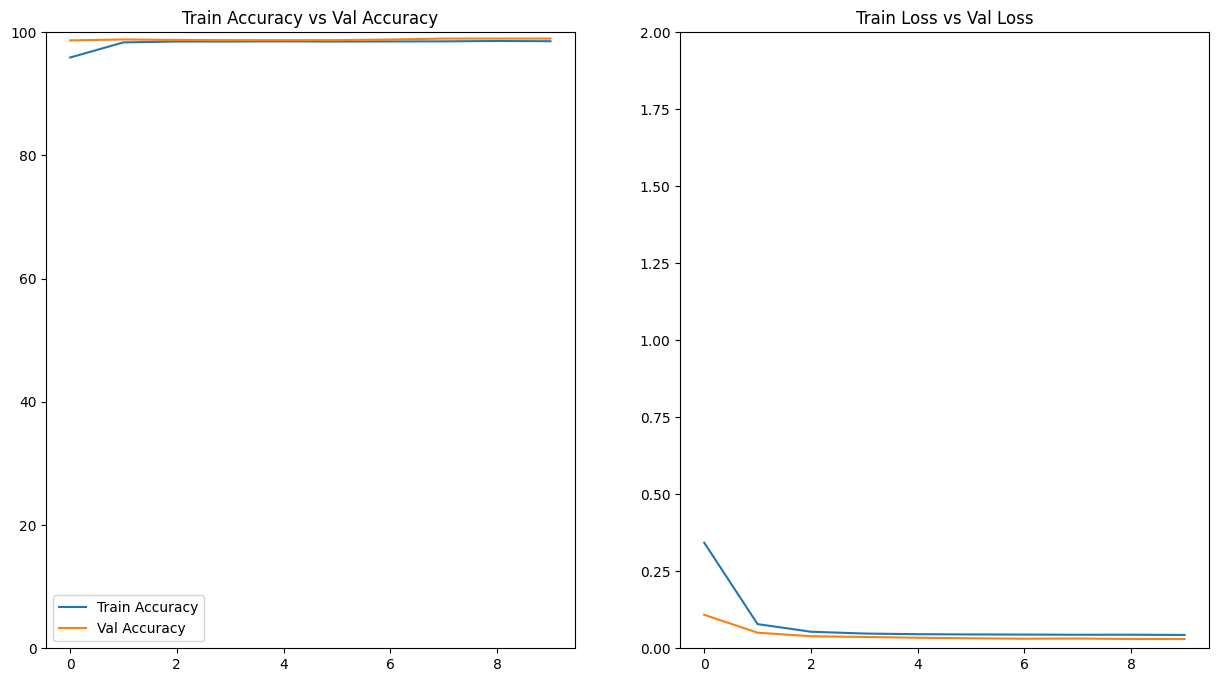

In [29]:
# Plot Train Accuracy vs Val Accuracy and Train Loss vs Val Loss

fig, axs = plt.subplots(1, 2, figsize=(15,8))
axs[0].plot(train_acc_per_epoch, label="Train Accuracy")
axs[0].plot(val_acc_per_epoch, label="Val Accuracy")
axs[0].set_title("Train Accuracy vs Val Accuracy")
axs[0].set_ylim(0, 100)
axs[0].legend()

axs[1].plot(train_loss_per_epoch, label="Train Loss")
axs[1].plot(val_loss_per_epoch, label="Val Loss")
axs[1].set_title("Train Loss vs Val Loss")
axs[1].set_ylim(0, 2)
axs[1].legend

plt.show()